***
<font size="2.5">
    
jyusuf & hussainu
</font>
    
<font size="+3.3">
    
**Machine Learning Project**
    
Data Preparation<p>
</font>
<p>
    



***

## Overview

Our Data Preparation is divided into 4 stages in this report
- Data Acquisition
- Data Analysis
- Data Wrangling
- Feature Engineering

***

# <center><font color='green'> 1. Data Acquisition</center>

***
## <font color='teal'> 1.1 Initial Raw Dataset Acquisition </font>

The raw dataset consists of 4 CSV files:

- `TMODULO.csv`
- `TSDEM.csv`
- `THOGAR.csv`
- `TVIVIENDA.csv`

These files were obtained from Mexico’s ENIF 2024 survey microdata and related documentation. The relevant source for the data can be found at the following URL:
- `https://en.www.inegi.org.mx/programas/enif/2024/#microdata`
Furthermore, the dictionary description for each variable/feature name's key is available under the below URL:
- `https://www.inegi.org.mx/rnm/index.php/catalog/1081/data-dictionary/F42?file_name=TMODULO`

Note that a large portion of the dataset is in Spanish. Therefore, we first translated the information available into English through a browser extension before inspecting the variables to see which are relevant for our task.

We selected this dataset because it contains a large number of observations and a wide variety of demographic, household, financial, and credit-related variables. At the same time, it requires substantial preprocessing, merging, and filtering before it becomes suitable for the machine learning use case we have.

We also chose this dataset because there is limited publicly available data in Mexico that fits our intended loan-analysis use case. Rather than working with a polished dataset from a narrower market that has already been heavily explored, we wanted to build our project around a dataset that better reflects the Mexican context and gives us more room for meaningful preprocessing and feature selection.

We plan to first merge the datasets since each of them do include important feature variables that we will need, and subsequently we will inspect the dataset to extract the useful features for our project based on filtering for relevance.

In [37]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "raw_data"


def read_csv(name):
    # Reading one CSV file from the raw_data folder
    return pd.read_csv(DATA_DIR / name, low_memory=False)


def tmodulo_values(df, suffix):
    # Combining overlapping TMODULO and TSDEM columns after merge
    suf_cols = [c for c in df.columns if c.endswith(suffix)]

    for c_suf in suf_cols:
        c_base = c_suf[:-len(suffix)]

        if c_base in df.columns:
            mask_missing = df[c_base].isna()
            df.loc[mask_missing, c_base] = df.loc[mask_missing, c_suf]
            df = df.drop(columns=[c_suf])

    return df


def aliasing_tsdem(df):
    # Filling important demographic columns from TSDEM aliases if needed
    aliases = {
        "EDAD_V": ["EDAD", "AGE"],
        "SEXO": ["SEX"],
        "PAREN": ["PAREN", "STOP"],
        "NIV": ["NIV", "LEVEL"],
        "GRA": ["GRA", "GRAL"],
        "ENT": ["ENT"],
        "TLOC": ["TLOC"],
        "REGION": ["REGION"],
    }

    for target, sources in aliases.items():
        if target not in df.columns:
            continue

        for src in sources:
            if src in df.columns and src != target:
                mask_missing = df[target].isna()
                df.loc[mask_missing, target] = df.loc[mask_missing, src]

    return df


# Reading the four raw CSV files
tsdem = read_csv("TSDEM.csv")
tmod = read_csv("TMODULO.csv")
thog = read_csv("THOGAR.csv")
tviv = read_csv("TVIVIENDA.csv")

# Keys for the merges
key_person = ["LLAVEVIV", "LLAVEHOG", "N_REN"]
key_hog = ["LLAVEVIV", "LLAVEHOG"]
key_viv = ["LLAVEVIV"]

# Ensuring important person-level keys exist first
for k in key_person:
    if k not in tsdem.columns:
        raise ValueError(f"TSDEM missing key column: {k}")
    if k not in tmod.columns:
        raise ValueError(f"TMODULO missing key column: {k}")

# Merging TMODULO with TSDEM first
df_raw = tmod.merge(tsdem, on=key_person, how="left", suffixes=("", "_SDE"))
df_raw = tmodulo_values(df_raw, suffix="_SDE")
df_raw = aliasing_tsdem(df_raw)

# Then merging THOGAR and TVIVIENDA
df_raw = df_raw.merge(thog, on=key_hog, how="left", suffixes=("", "_HOG"))
df_raw = df_raw.merge(tviv, on=key_viv, how="left", suffixes=("", "_VIV"))

# Printing shape so we can confirm merging
print("Merged raw dataframe shape:", df_raw.shape)
print("First 20 columns:", list(df_raw.columns[:20]))

Merged raw dataframe shape: (13502, 427)
First 20 columns: ['LLAVEMOD', 'LLAVEVIV', 'LLAVEHOG', 'EDAD_V', 'NIV', 'GRA', 'P3_1A', 'P3_2', 'P3_3', 'P3_4', 'P3_5_1', 'P3_5_2', 'P3_5_3', 'P3_5_4', 'P3_5_5', 'P3_5_6', 'P3_5_7', 'P3_5_8', 'P3_6', 'P3_7']


## <font color='teal'> 1.2 Filtering Variables for Relevance </font>

After acquiring the raw datasets, the next step was to identify which variables were actually relevant to our loan-analysis use case. Since the ENIF survey was designed for broad financial inclusion analysis rather than specifically for loan-risk prediction, many of its variables were not directly useful for our project. Therefore, we filtered the merged data to keep only the features that could help describe a person’s financial situation, household background, and credit-related behavior.

We excluded variables that were mainly administrative or not useful for our task, such as identification keys, survey-flow fields, and other attributes that would not meaningfully help with loan-risk analysis. At this stage, our goal was not yet to clean or engineer the data, but simply to reduce the raw survey to a more relevant subset.

Instead, we kept variables that are more closely related to the kind of information a lender or financial institution might use when assessing an applicant. These included broad profile variables, employment and income information, daily functioning information, savings and financial stability information, household and housing information, insurance information, basic financial knowledge, asset ownership, and formal credit ownership. We also retained the `P6_3_*` and `P6_4_*` credit-related variables, since these may later be used to construct targets related to missed payments and repayment difficulty.

For clarity, we organized the selected variables into feature categories, based on how the original dataset broadly groups its survey questions:

1. **Base demographics** (8)  
2. **P0 — Dwelling / home characteristics** (4)  
3. **P1 — Household structure** (1)  
4. **P2 — Household economic participation** (1)  
5. **P3 — Personal demographic and socioeconomic profile** (8)  
6. **P4 — Budgeting, financial behavior, and vulnerability** (4)  
7. **P6 — Credit ownership / formal credit profile** (9)  
8. **P8 — Insurance** (4)  
9. **P12 — Financial literacy** (3)  
10. **P13 — Assets** (2)

At this stage, our relevance-filtered dataset contains **44 selected predictor features** for later modeling, in addition to the retained `P6_3_*` and `P6_4_*` variables that may be used later for target construction. This is still not the final feature set, and we expect to refine it further in the **Feature Engineering** stage after performing **Data Analysis**.

**Note:** Executing the filtering code creates a new output file in the project folder’s `outputs` directory called `relevant_project_data.csv`. This file is after extracting our relevant feartures for the merged dataset, which we will use as the starting point for later stages of the pipeline.

In [38]:
OUT_DIR = BASE_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def pick_existing(df, cols):
    # Picking existing columns
    seen = set()
    out = []

    for c in cols:
        if c in df.columns and c not in seen:
            out.append(c)
            seen.add(c)

    return out


def make_feature_lists(df):
    # Organizing relevant columns into base demographics and selected features
    base_demographics = [
        "EDAD_V", "SEXO", "NIV", "GRA", "PAREN", "ENT", "TLOC", "REGION"
    ]

    # P3 — Demographic and socioeconomic profile
    p3_features = [
        "P3_2", "P3_8", "P3_10",
        "P3_11A", "P3_11B", "P3_12", "P3_14",
        "P3_5_5",
    ]

    # P4 — Financial behaviour
    p4_features = ["P4_1", "P4_3", "P4_10", "P4_11"]

    # P0, P1, P2 — Household
    household_features = [
        "P0_1", "P0_2", "P0_3", "P0_4_2",
        "P1_1", "P2_8",
    ]

    # P6 — Credit
    p6_features = [f"P6_2_{i}" for i in range(1, 10)]

    # P8 — Insurance
    p8_features = ["P8_1", "P8_5_1", "P8_5_2", "P8_5_3"]

    # P12 — Financial literacy
    p12_features = ["P12_2", "P12_3", "P12_4"]

    # P13 — Assets
    p13_features = ["P13_2_1", "P13_2_2"]

    selected_features = (
        p3_features
        + p4_features
        + household_features
        + p6_features
        + p8_features
        + p12_features
        + p13_features
    )

    base_demographics = pick_existing(df, base_demographics)
    selected_features = pick_existing(df, selected_features)

    return base_demographics, selected_features


# Keeping useful id columns so rows can still be traced back later
id_cols = [c for c in [
    "LLAVESDE", "LLAVEMOD", "LLAVEVIV", "LLAVEHOG", "N_REN",
    "FOLIO", "VIV_SEL", "HOGAR"
] if c in df_raw.columns]

# Getting selected relevant feature columns
base_demographics, selected_features = make_feature_lists(df_raw)

# Keeping P6_3 and P6_4 columns for later target construction
target_source_cols = (
    [f"P6_3_{i}" for i in range(1, 10)] +
    [f"P6_4_{i}" for i in range(1, 10)]
)
target_source_cols = pick_existing(df_raw, target_source_cols)

# Building a relevance-filtered table without doing cleaning or feature engineering yet
selected_cols = id_cols + base_demographics + selected_features + target_source_cols
selected_cols = pick_existing(df_raw, selected_cols)

df_relevant = df_raw[selected_cols].copy()

# Saving the filtered table for later sections
out_file = OUT_DIR / "relevant_project_data.csv"
df_relevant.to_csv(out_file, index=False, encoding="utf-8")

print(f"Confirming Saved Location: {out_file}")
print("Relevant dataframe shape:", df_relevant.shape)
print("Base demographics:", base_demographics)
print("Selected features:", selected_features)
print("Target source columns:", target_source_cols)

Confirming Saved Location: /Users/hussainbinusman/Documents/ML project/outputs/relevant_project_data.csv
Relevant dataframe shape: (13502, 70)
Base demographics: ['EDAD_V', 'SEXO', 'NIV', 'GRA', 'PAREN', 'ENT', 'TLOC', 'REGION']
Selected features: ['P3_2', 'P3_8', 'P3_10', 'P3_11A', 'P3_11B', 'P3_12', 'P3_14', 'P3_5_5', 'P4_1', 'P4_3', 'P4_10', 'P4_11', 'P0_1', 'P0_2', 'P0_3', 'P0_4_2', 'P1_1', 'P2_8', 'P6_2_1', 'P6_2_2', 'P6_2_3', 'P6_2_4', 'P6_2_5', 'P6_2_6', 'P6_2_7', 'P6_2_8', 'P6_2_9', 'P8_1', 'P8_5_1', 'P8_5_2', 'P8_5_3', 'P12_2', 'P12_3', 'P12_4', 'P13_2_1', 'P13_2_2']
Target source columns: ['P6_3_1', 'P6_3_2', 'P6_3_3', 'P6_3_4', 'P6_3_5', 'P6_3_6', 'P6_3_7', 'P6_3_8', 'P6_3_9', 'P6_4_1', 'P6_4_2', 'P6_4_3', 'P6_4_4', 'P6_4_5', 'P6_4_6', 'P6_4_7', 'P6_4_8', 'P6_4_9']


## <font color='teal'> 1.3 Initial Feature & Target Construction </font>

Since the variables under `P6_3_*` describe whether a person fell behind on payments for different types of formal credit, and the variables under `P6_4_*` describe the seriousness of those delayed payments, we use them as the basis for our initial supervised targets. In other words, using a person’s selected features — such as age, income, household background, financial behavior, insurance information, and formal credit profile — we aim to predict repayment difficulty.

From these credit-related variables, we construct the following initial targets through a simple functions:

- **`delinquent_any`**: a binary classification target equal to `1` if the person fell behind on payments for at least one formal credit product, and `0` otherwise.

- **`delinquent_count`**: a count-based target equal to the number of formal credit products for which the person fell behind on payments.

These are the two main targets we identified for our supervised model: one for classification (`delinquent_any`) and one for regression (`delinquent_count`), which will be predicted by the features.

In [39]:
def build_targets(df):
    # Constructing initial target variables from the P6_3 columns
    df = df.copy()

    p63_cols = [f"P6_3_{i}" for i in range(1, 10)]
    p63_cols = pick_existing(df, p63_cols)

    # Creating binary target for whether person was delinquent on any formal credit
    if p63_cols:
        delinquent_flags = df[p63_cols].eq(1)

        df["delinquent_any"] = delinquent_flags.any(axis=1).astype(int)
        df["delinquent_count"] = delinquent_flags.sum(axis=1)
    else:
        df["delinquent_any"] = pd.NA
        df["delinquent_count"] = pd.NA

    return df


# Adding target columns onto the relevance-filtered dataset
df_relevant = build_targets(df_relevant)

# Saving updated version back to the same output file
out_file = OUT_DIR / "relevant_project_data.csv"
df_relevant.to_csv(out_file, index=False, encoding="utf-8")

print("Updated dataframe shape:", df_relevant.shape)
print("Target columns added:", ["delinquent_any", "delinquent_count"])
print(df_relevant[["delinquent_any", "delinquent_count"]].head())


Updated dataframe shape: (13502, 72)
Target columns added: ['delinquent_any', 'delinquent_count']
   delinquent_any  delinquent_count
0               0                 0
1               0                 0
2               0                 0
3               0                 0
4               0                 0


## <font color='teal'> 1.4 Data Synthesis for Customisation </font>

Although the ENIF dataset already gives us a lot of useful real information about a person, it still does not fully place them in a loan-request situation. For our project, we want the use case to feel closer to a real lending setting, where a lender would care not only about the applicant’s background, but also about how much they want to borrow and over what time period. To make the dataset better match this use case, we synthetically add two new variables: **`loan_amount_requested`** and **`requested_term_months`**.

These variables make the project more realistic without replacing the original data. Instead of only describing a person’s demographic, financial, and household profile, the dataset can now also describe a possible borrowing scenario. This helps connect our real survey data more clearly to the loan-analysis task we want to study.

The synthetic variables are not generated randomly from scratch. Instead, they are based on patterns from the real features already in the dataset. For example, the requested loan amount depends on factors such as income, income stability, savings, financial behaviour, asset ownership, insurance, and whether the person already has formal credit. In general, a person with a stronger financial profile is linked to a larger requested amount, while a more financially vulnerable person is usually linked to a smaller one. The requested term then depends partly on the requested amount, since larger loans are usually associated with longer repayment periods.

To make the synthetic data more realistic, we also include a small amount of random variation. This is important so that the values do not all follow the exact same pattern. For reproducibility, the synthetic variables are generated using a fixed random seed of **15288**.

Most importantly, our main supervised targets still remain based on the real `P6_3_*` survey variables, while the `P6_4_*` variables may later help us define an additional target related to repayment severity. This means the predictive task stays grounded in the original dataset, while the synthetic variables are only used to customize the dataset and make the lending scenario more realistic.`

In [40]:
import numpy as np

# Setting random seed for reproducibility
RANDOM_STATE = 15288
np.random.seed(RANDOM_STATE)

# Counting selected owned assets
asset_cols = pick_existing(df_relevant, ["P13_2_1", "P13_2_2"])
if asset_cols:
    asset_score = df_relevant[asset_cols].eq(1).sum(axis=1)
else:
    asset_score = pd.Series(0, index=df_relevant.index)

# Counting selected insurance types
insurance_cols = pick_existing(df_relevant, ["P8_5_1", "P8_5_2", "P8_5_3"])
if insurance_cols:
    insurance_score = df_relevant[insurance_cols].eq(1).sum(axis=1)
else:
    insurance_score = pd.Series(0, index=df_relevant.index)

# Counting formal credit ownership
credit_cols = pick_existing(df_relevant, [f"P6_2_{i}" for i in range(1, 10)])
if credit_cols:
    credit_score = df_relevant[credit_cols].eq(1).sum(axis=1)
else:
    credit_score = pd.Series(0, index=df_relevant.index)

# Using selected financial columns from the dataset
income = df_relevant["P3_11A"]
income_stability = df_relevant["P3_12"]
savings = df_relevant["P4_10"]
expense_cover = df_relevant["P4_3"]

# Creating a score for requested loan amount
loan_score = (
    0.45 * income.rank(pct=True)
    + 0.15 * (1 - income_stability.rank(pct=True))
    + 0.20 * savings.rank(pct=True)
    + 0.10 * (1 - expense_cover.rank(pct=True))
    + 0.05 * asset_score.rank(pct=True)
    + 0.03 * insurance_score.rank(pct=True)
    + 0.02 * credit_score.rank(pct=True)
)
loan_score = loan_score.fillna(loan_score.median())

# Creating synthetic loan amount requested
loan_amount_requested = 3000 + 200000 * loan_score

# Adding some random noise
loan_amount_requested = loan_amount_requested + np.random.normal(0, 12000, len(df_relevant))

# Ensuring within reasonable range
loan_amount_requested = pd.Series(loan_amount_requested, index=df_relevant.index)
loan_amount_requested[loan_amount_requested < 2000] = 2000
loan_amount_requested[loan_amount_requested > 300000] = 300000
loan_amount_requested = loan_amount_requested.round(-2)

df_relevant["loan_amount_requested"] = loan_amount_requested.astype(int)

# Creating synthetic requested term in months
requested_term_months = 6 + 48 * df_relevant["loan_amount_requested"].rank(pct=True)

# Letting savings and stability slightly affect the term
requested_term_months = requested_term_months + 4 * savings.rank(pct=True) + 4 * (1 - income_stability.rank(pct=True))

# Adding some random variation
requested_term_months = requested_term_months + np.random.normal(0, 3, len(df_relevant))

# Defining range for values
requested_term_months = pd.Series(requested_term_months, index=df_relevant.index)
requested_term_months[requested_term_months < 6] = 6
requested_term_months[requested_term_months > 60] = 60

# Rounding loan terms
common_terms = [6, 12, 18, 24, 36, 48, 60]
requested_term_months = requested_term_months.apply(
    lambda x: min(common_terms, key=lambda t: abs(t - x))
)

df_relevant["requested_term_months"] = requested_term_months.astype(int)

# Saving updated dataframe
out_file = OUT_DIR / "relevant_project_data.csv"
df_relevant.to_csv(out_file, index=False, encoding="utf-8")

print("Updated dataframe shape:", df_relevant.shape)
print(df_relevant[["loan_amount_requested", "requested_term_months"]].head())

Updated dataframe shape: (13502, 74)
   loan_amount_requested  requested_term_months
0                 135400                     60
1                 134600                     48
2                 114000                     48
3                 110600                     48
4                  61100                     12


***
# <center><font color='green'> 2. Data Analysis</center>

## <font color='teal'> 2.1 Numeric Feature Distributions </font>

To begin the data analysis, we first inspect the distributions of some important numeric variables in the dataset. This helps us understand how the values are spread, whether certain variables are skewed, and whether there are any unusual patterns that may matter later for wrangling or modeling.

In particular, we focus on a mix of real and synthetic numeric variables. This allows us to compare the behavior of original survey-based features, such as income and financial vulnerability, with the new loan-related variables we added for customization. Looking at these distributions gives us an initial sense of whether the synthetic variables behave reasonably in relation to the real dataset.

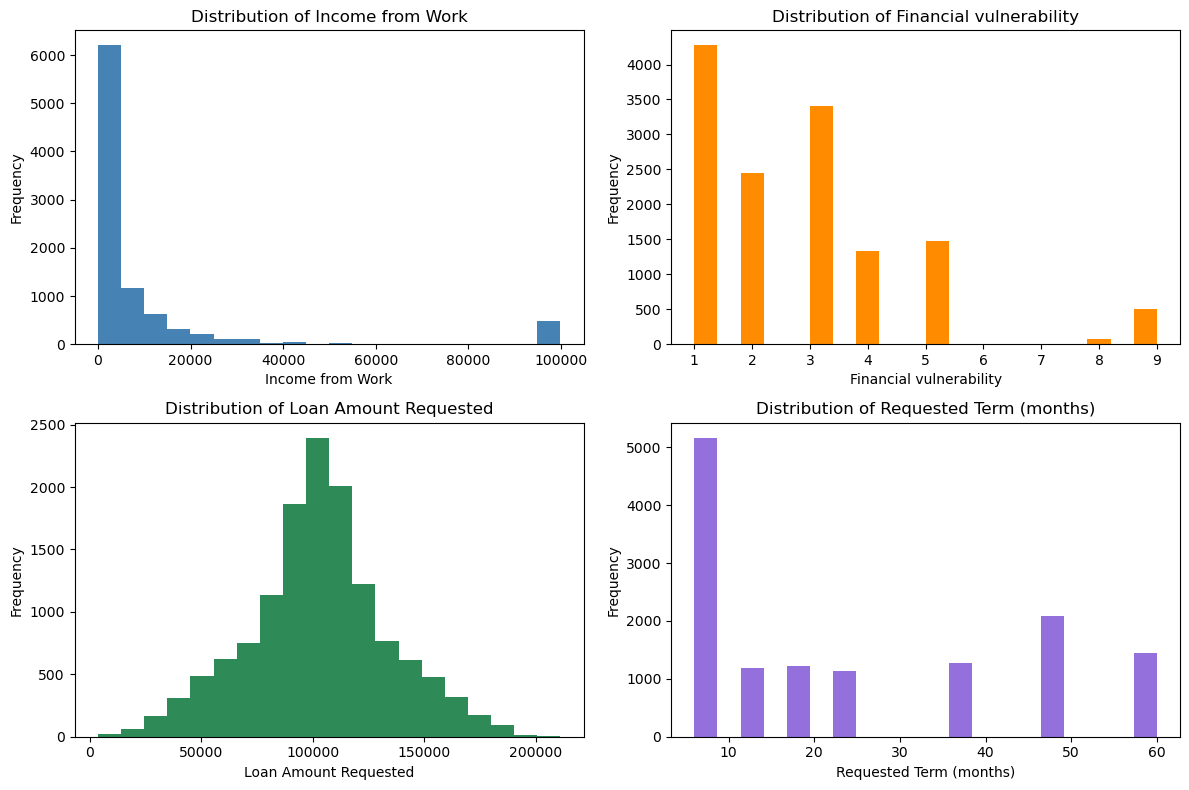

In [37]:
import matplotlib.pyplot as plt

# Mapping variable names to readable labels through dictionary
feature_labels = {
    "P3_11A": "Income from Work",
    "P4_10": "Financial vulnerability",
    "loan_amount_requested": "Loan Amount Requested",
    "requested_term_months": "Requested Term (months)"
}

# Choosing important numeric features to inspect first
numeric_columns = [
    "P3_11A",
    "P4_10",
    "loan_amount_requested",
    "requested_term_months"
]

# Choosing different colors for each histogram
plot_colors = ["steelblue", "darkorange", "seagreen", "mediumpurple"]

# Keeping columns existing in the dataframe
numeric_columns = [col for col in numeric_columns if col in df_relevant.columns]

# Creating figure and axes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Histograms for selected numeric columns
for i, col in enumerate(numeric_columns):
    label = feature_labels.get(col, col)

    axes[i].hist(df_relevant[col].dropna(), bins=20, color=plot_colors[i])
    axes[i].set_title(f"Distribution of {label}")
    axes[i].set_xlabel(label)
    axes[i].set_ylabel("Frequency")

# Removing unused axes if needed
for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])

# Adjusting layout so plots do not overlap
plt.tight_layout()

plt.show()

The histograms gives an initial view of the distributions of the important numeric variables in the dataset.

The distribution of **`P3_11A`** (income from work) is heavily right-skewed. Most observations are concentrated at lower income values, while a smaller number of observations extend to much larger values. This suggests that income is not evenly distributed in the dataset, and that there may be some high-income outliers that should be kept in mind during later stages of analysis.

The distribution of **`P4_10`** is discrete rather than continuous, since it comes from survey response categories. Most responses are concentrated in the lower categories, with fewer responses in the higher ones. This suggests that financial vulnerability is not spread evenly across the respondents, and that some categories may be much more common than others.

The synthetic variable **`loan_amount_requested`** appears roughly bell-shaped, with most values concentrated around the middle of the range and fewer observations at the extremes. This is a good sign, since it shows that the synthetic loan amounts were not generated as completely random values, but still follow a structured distribution linked to the real dataset.

The synthetic variable **`requested_term_months`** is also discrete, since it was rounded to common loan durations such as 6, 12, 24, 36, 48, and 60 months. The strongest concentration appears at shorter terms, especially 6 months, while longer terms appear less frequently. This makes sense in a lending context, since shorter repayment periods are often more common than very long ones.

Overall, these plots show that the dataset contains a mix of highly skewed real variables, categorical-style numeric variables, and newly synthesized loan-request variables. These observations will be useful later when deciding whether some features need further processing or transformation before modeling.

## <font color='teal'> 2.2 Boxplots for Key Numeric Features </font>

In addition to histograms and summary statistics, boxplots provide another useful way to examine numeric variables. They help us visualize the median, spread, and possible outliers more clearly, which is especially helpful for variables that may be skewed.

Here, we will focus on the same important numeric variables used earlier. This allows us to compare the real dataset features with the synthetic loan-related variables in a more compact visual form, and to better see whether extreme values are present.

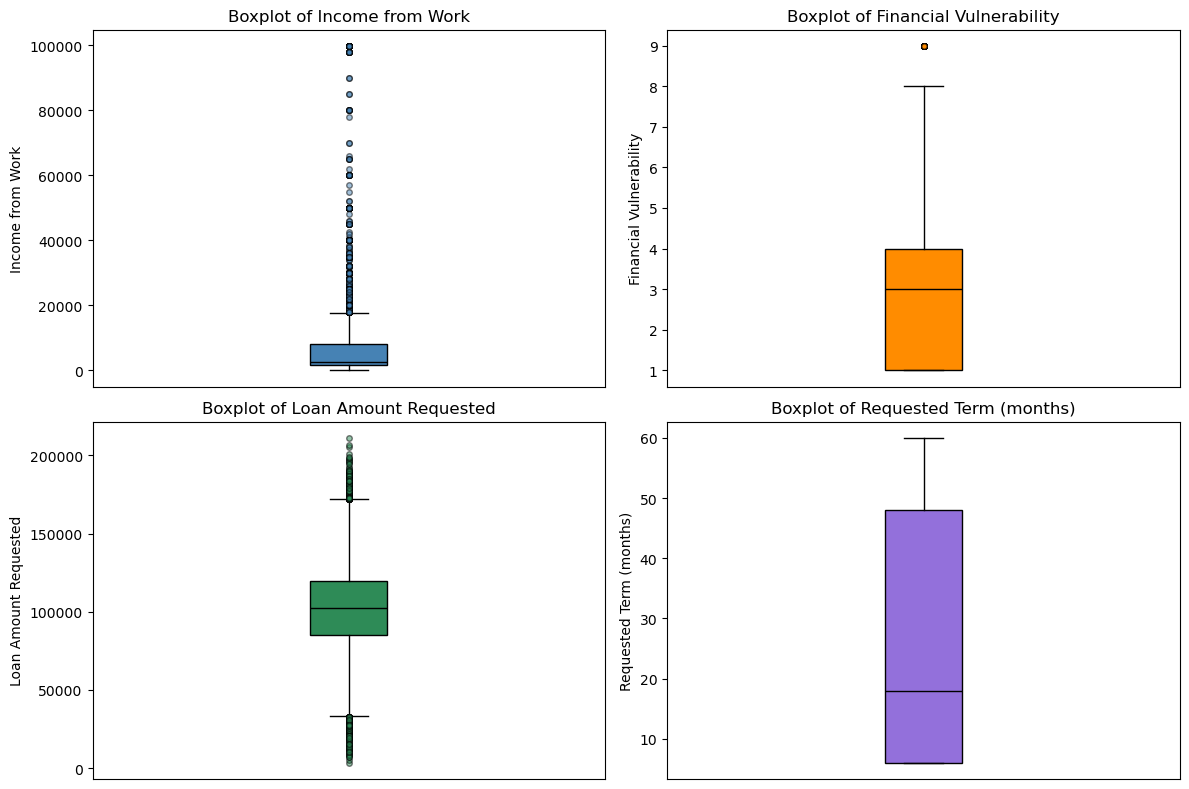

In [45]:
import matplotlib.pyplot as plt

# Keeping columns existing in the dataframe
numeric_columns = [col for col in numeric_columns if col in df_relevant.columns]

# Creating figure and axes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Boxplots for selected numeric columns
for i, col in enumerate(numeric_columns):
    label = feature_labels.get(col, col)

    axes[i].boxplot(
        df_relevant[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=plot_colors[i]),
        medianprops=dict(color="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(marker="o", markerfacecolor=plot_colors[i], markersize=4, alpha=0.5)
    )
    axes[i].set_title(f"Boxplot of {label}")
    axes[i].set_ylabel(label)
    axes[i].set_xticks([])

# Removing unused axes if needed
for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])

# Adjusting layout so plots do not overlap
plt.tight_layout()

plt.show()

- **Income from Work:** The boxplot confirms the strong right-skew seen earlier in the histogram. Most observations are concentrated at the lower end, while many high-income values appear as outliers. This shows that income is spread very unevenly across respondents, with a small number of much larger values.

- **Financial Vulnerability:** The boxplot shows a much more limited and discrete spread, which is expected because this variable comes from survey response categories rather than a continuous measurement. Most observations are concentrated around the middle categories, with relatively less variation than income.

- **Loan Amount Requested:** The boxplot shows that most synthetic loan amounts are concentrated around the middle of the range, while a smaller number of lower and higher values appear as outliers. This suggests that the synthetic loan amounts have a reasonable spread while still allowing some more extreme borrowing scenarios.

- **Requested Term (months):** The boxplot reflects the fact that this variable is discrete and restricted to common loan durations. The spread is fairly wide, but the values remain within a realistic range from shorter to longer repayment periods.

These observations align with the findings from the earlier histograms, while also giving a clearer view of the spread, concentration, and outliers in each variable.

## <font color='teal'> 2.3 Categorical Feature Distributions </font>

After looking at the numeric variables, we next inspect a few important categorical or grouped features in the dataset. This helps us understand how common different categories are, whether some groups appear much more often than others, and whether any strong imbalance may affect later modeling decisions.

In this section, we focus on selected grouped features that are relevant to our use case, such as formal credit ownership, insurance-related variables, and other survey-based categorical fields. Since many variables in this dataset come from survey responses rather than continuous measurements, looking at their category frequencies is important for understanding the overall structure of the data.

These plots also help us see whether some categories are very rare or very dominant. This can later guide our choices in data wrangling, feature engineering, and model preparation, especially when deciding how to handle categorical variables and whether some features need to be simplified or grouped further.

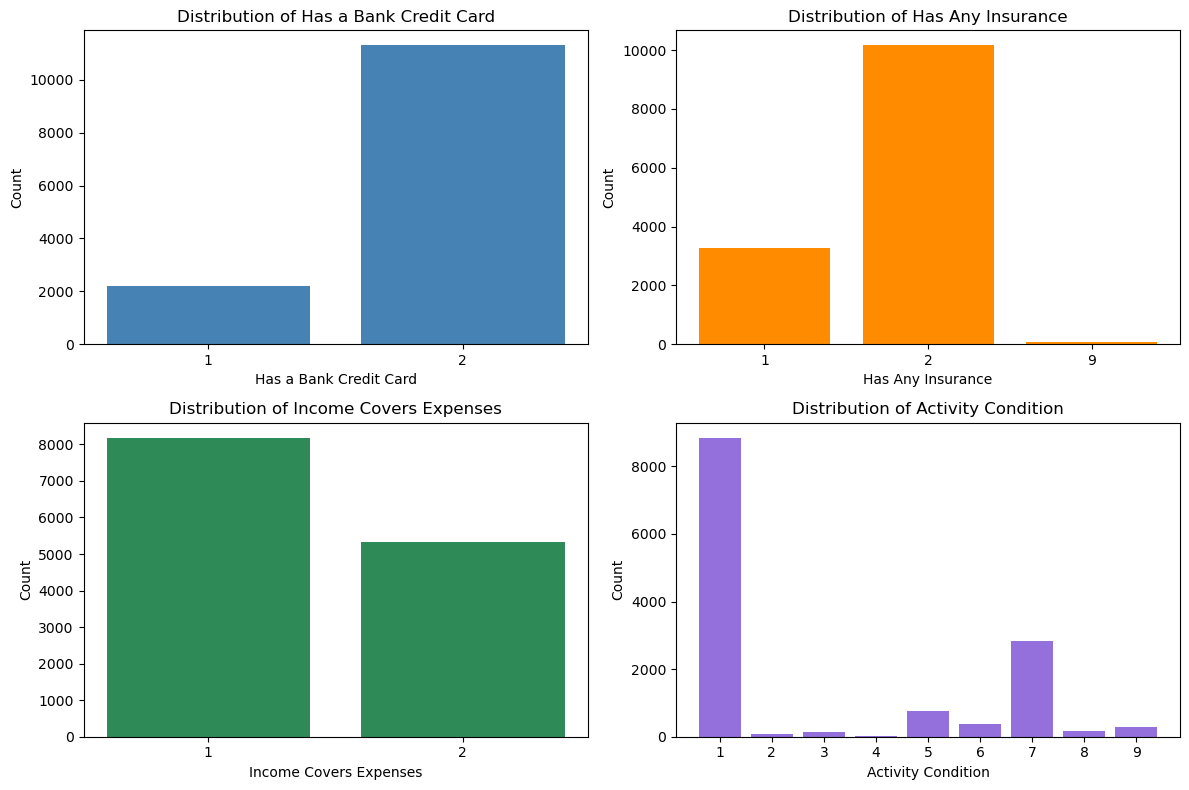

In [46]:
import matplotlib.pyplot as plt

# Mapping variable names to readable labels through dictionary
feature_labels = {
    "P6_2_2": "Has a Bank Credit Card",
    "P8_1": "Has Any Insurance",
    "P4_3": "Income Covers Expenses",
    "P3_8": "Activity Condition"
}

# Choosing important grouped categorical features to inspect
categorical_columns = [
    "P6_2_2",
    "P8_1",
    "P4_3",
    "P3_8"
]

# Keeping columns existing in the dataframe
categorical_columns = [col for col in categorical_columns if col in df_relevant.columns]

# Creating figure and axes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Bar plots for the categorical columns
for i, col in enumerate(categorical_columns):
    label = feature_labels.get(col, col)
    value_counts = df_relevant[col].value_counts(dropna=False).sort_index()

    axes[i].bar(value_counts.index.astype(str), value_counts.values, color=plot_colors[i])
    axes[i].set_title(f"Distribution of {label}")
    axes[i].set_xlabel(label)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', labelrotation=0)

# Removing unused axes if needed
for j in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[j])

# Adjusting layout so plots do not overlap
plt.tight_layout()

plt.show()

The grouped feature distributions provide a clearer picture of how some important categorical survey variables are spread across the dataset.

For **`P6_2_2`**, which represents whether the respondent has a bank credit card, the plot is clearly imbalanced. Most respondents fall into one category, while a smaller group falls into the other. This suggests that formal credit ownership is not evenly distributed, which may later affect how much this feature contributes to predicting delinquency.

For **`P8_1`**, which shows whether the respondent has any insurance, we again see that one category is much more common than the others. There is also a very small count in category `9`, which may represent a special coded response and should be checked later during data wrangling.

The distribution of **`P4_3`**, which relates to whether the respondent’s income is enough to cover expenses, is less imbalanced than the previous two variables. Both categories have substantial counts, although one still appears more often. This suggests that this feature may be informative, since it separates respondents into two fairly meaningful groups.

Finally, **`P3_8`**, which represents activity condition, is spread across multiple categories, but one category is clearly dominant. The remaining categories appear much less frequently, which suggests that this variable may later need careful treatment if the rare categories are too sparse.

Overall, these grouped distributions show that several of the survey-based categorical variables are imbalanced. This is useful for later stages, since it suggests that some categorical features may need cleaning, regrouping, or special handling before modeling.

## <font color='teal'> 2.4 Target Distributions </font>

After examining the selected numeric and grouped features, we next inspect the distributions of our constructed target variables. This is an important step because it helps us understand how balanced or imbalanced the prediction task is before moving to modeling.

In this project, the two main targets are **`delinquent_any`** and **`delinquent_count`**. The first is a binary target that shows whether a person fell behind on at least one formal credit product, while the second counts how many formal credit products they fell behind on. Looking at these target distributions helps us understand how common repayment difficulty is in the dataset and whether class imbalance may become an issue later.

This section is especially useful for deciding how we should approach the supervised task. If one target class is much more common than the other, then later model evaluation will need to take that imbalance into account rather than relying only on raw accuracy.

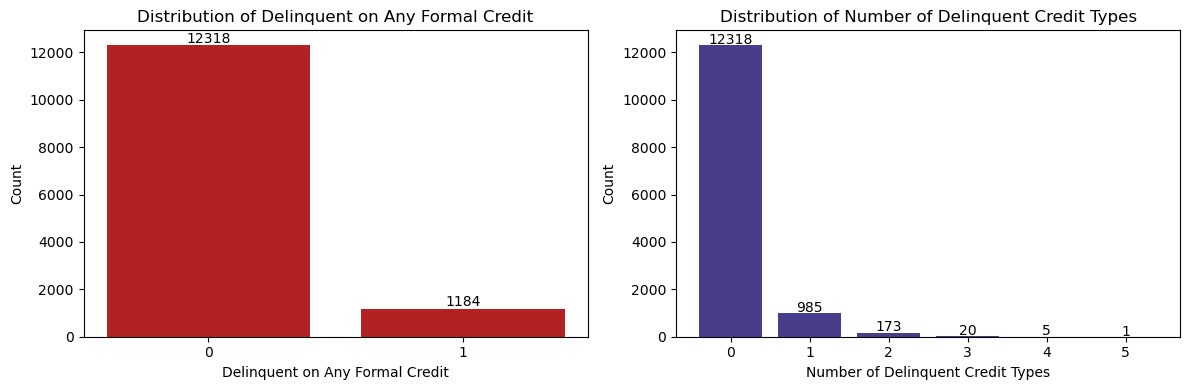

In [47]:
import matplotlib.pyplot as plt

# Mapping target names to readable labels through dictionary
target_labels = {
    "delinquent_any": "Delinquent on Any Formal Credit",
    "delinquent_count": "Number of Delinquent Credit Types"
}

# Colors for target plots
plot_colors = ["firebrick", "darkslateblue"]

# Figare and Axes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot for binary target
delinquent_any_counts = df_relevant["delinquent_any"].value_counts().sort_index()

axes[0].bar(
    delinquent_any_counts.index.astype(str),
    delinquent_any_counts.values,
    color=plot_colors[0]
)
axes[0].set_title(f"Distribution of {target_labels['delinquent_any']}")
axes[0].set_xlabel(target_labels["delinquent_any"])
axes[0].set_ylabel("Count")

# Count labels above bars
for i, value in enumerate(delinquent_any_counts.values):
    axes[0].text(i, value + 100, str(value), ha="center")

# Bar plot for count target
delinquent_count_counts = df_relevant["delinquent_count"].value_counts().sort_index()

axes[1].bar(
    delinquent_count_counts.index.astype(str),
    delinquent_count_counts.values,
    color=plot_colors[1]
)
axes[1].set_title(f"Distribution of {target_labels['delinquent_count']}")
axes[1].set_xlabel(target_labels["delinquent_count"])
axes[1].set_ylabel("Count")

# Writing count labels above bars
for i, value in enumerate(delinquent_count_counts.values):
    axes[1].text(i, value + 50, str(value), ha="center")

plt.tight_layout() #toavoid overlap

plt.show()

## <font color='teal'> 2.5 Summary Statistics for Key Numeric Features </font>

After visualizing the distributions of selected numeric variables, it is also useful to examine their summary statistics. This helps us better understand the central tendency, spread, and range of the values in the dataset.

In this section, we focus on a small group of important numeric variables from both the original dataset and the synthetic customization stage. By comparing their summary statistics, we can better understand how these variables differ in scale and variation, which could later guide decisions in data wrangling and modeling.

In [41]:
# Mapping variable names to readable labels through dictionary
feature_labels = {
    "P3_11A": "Income from Work",
    "P4_10": "Financial Vulnerability",
    "loan_amount_requested": "Loan Amount Requested",
    "requested_term_months": "Requested Term (months)"
}

# Choosing important numeric features to summarize
numeric_columns = [
    "P3_11A",
    "P4_10",
    "loan_amount_requested",
    "requested_term_months"
]

# Keeping columns existing in the dataframe
numeric_columns = [col for col in numeric_columns if col in df_relevant.columns]

# Creating summary statistics table
summary_stats = df_relevant[numeric_columns].describe().T

# Renaming index labels to readable names
summary_stats.index = [feature_labels.get(col, col) for col in summary_stats.index]

display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
Income from Work,9368.0,10321.470325,22289.974012,0.0,1500.0,2500.0,8000.0,99888.0
Financial Vulnerability,13502.0,2.751963,1.840510,1.0,1.0,3.0,4.0,9.0
Loan Amount Requested,13502.0,102551.185010,31227.373186,3600.0,85200.0,102400.0,119900.0,211000.0
Requested Term (months),13502.0,24.207969,19.516092,6.0,6.0,18.0,48.0,60.0


## <font color='teal'> 2.6 Correlation Heatmap for Selected Numeric Features </font>

To better understand how some of the main numeric variables relate to one another, we also examine a correlation heatmap. This is useful because it shows whether certain features tend to move together, which may later affect feature selection and interpretation.

In this case, we focus on a small set of important numeric variables from both the original dataset and the synthetic customization stage. Since some of these variables were used in constructing the synthetic loan-related features, the heatmap also helps us check whether those new variables behave in a reasonable way relative to the existing data.

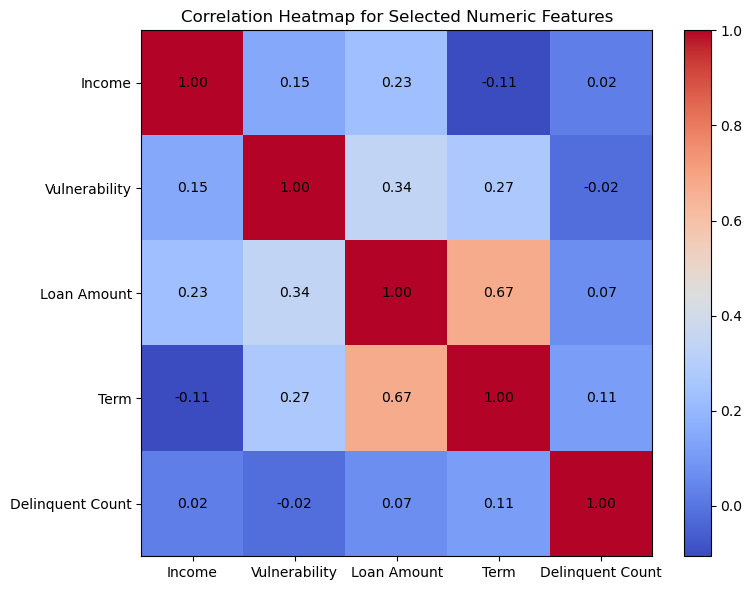

In [49]:
import matplotlib.pyplot as plt

# Mapping variable names to shorter readable labels
feature_labels = {
    "P3_11A": "Income",
    "P4_10": "Vulnerability",
    "loan_amount_requested": "Loan Amount",
    "requested_term_months": "Term",
    "delinquent_count": "Delinquent Count"
}

# Choosing selected numeric columns for the heatmap
heatmap_columns = [
    "P3_11A",
    "P4_10",
    "loan_amount_requested",
    "requested_term_months",
    "delinquent_count"
]

# Keeping columns existing in the dataframe
heatmap_columns = [col for col in heatmap_columns if col in df_relevant.columns]

# Computing correlation matrix
corr_matrix = df_relevant[heatmap_columns].corr()

# Creating figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plotting heatmap
im = ax.imshow(corr_matrix, aspect="auto", cmap="coolwarm")

# Setting tick labels
labels = [feature_labels.get(col, col) for col in heatmap_columns]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=0)
ax.set_yticklabels(labels)

# Writing correlation values inside each cell
for i in range(len(heatmap_columns)):
    for j in range(len(heatmap_columns)):
        value = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center")

# Adding title and colorbar
ax.set_title("Correlation Heatmap for Selected Numeric Features")
fig.colorbar(im)

# Adjusting layout so labels do not overlap
plt.tight_layout()

plt.show()

The correlation heatmap helps show how the selected numeric variables relate to one another more directly.

- **Income and Vulnerability:** These have only a weak positive correlation (0.15). This suggests that the two variables are related to some extent, but they are not measuring the same thing and may each provide different information to the model.

- **Loan Amount and Term:** These have the strongest correlation in the heatmap (0.67). This is expected, since the requested term was partly constructed from the loan amount, and in general larger loans are associated with longer repayment periods.

- **Synthetic variables and real variables:** The synthetic **Loan Amount** has a moderate positive correlation with **Vulnerability** (0.34) and a weaker positive correlation with **Income** (0.23). This suggests that the synthesized loan feature is meaningfully related to the real dataset rather than being independent random noise. Hence, this is a positive indication of our data synthesis being quite successful, although of course data wrangling will need to deal further with it in the next section

- **Delinquent Count:** This has only very weak correlations with the other selected numeric variables, with values close to 0. This suggests that repayment difficulty is not explained by any one numeric variable alone, and that it may depend on a broader combination of demographic, financial, and credit-related factors. This is very important to note, since it implies that our ML problem is not that straightforward to solve, and would need a complex solution to map the underlying relationship.

The most crucial takeaway from the heatmap is that clearly the target remains more weakly related to any single numeric feature on its own (our identified problem is not trivial to solve) - thus our model will need to be complex to solve the problem, and we would need to try different models through iterations.

***
# <center><font color='green'> 3. Data Wrangling</center>

## 3. Data Wrangling

After completing data acquisition and exploratory data analysis, the next step in the machine learning workflow is data wrangling. This corresponds to transforming raw data into a consistent feature representation that can later be used to construct a supervised learning dataset.

$$
D = \{(x^{(i)}, y^{(i)})\}_{i=1}^{m}
$$

where each \( x^{(i)} \) is a valid feature vector and each \( y^{(i)} \) is a well-defined target. In other words, wrangling prepares the data so that it can support the canonical supervised learning problem discussed in class.

Because our data comes from a real socioeconomic survey, it naturally contains issues such as:
- missing values,
- inconsistent data types,
- extreme numeric values,
- redundant columns,
- and non-predictive identifier variables.

The objective of this section is to detect and correct these issues before moving to feature engineering. This is important because downstream models optimize an empirical loss over the available training examples, and poor-quality inputs can distort both the empirical error and the estimated generalization performance. 

***
## <font color='teal'> 3.1 Data type inspection and feature-space consistency </font>


Before handling missing values or outliers, we first inspect the data types of the variables. This step is necessary because different preprocessing operations apply to different feature types.

some variables are naturally numeric, while others are categorical or coded survey responses. If we mis-handle these types, the resulting feature vectors may become inconsistent or misleading for the learning algorithm.

In [44]:
# Displaying the data type of every column
# This helps us understand which features are numeric and which are categorical
print(df_relevant.dtypes.sort_values())

# Split the columns into numeric and categorical groups
numeric_cols = df_relevant.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_relevant.select_dtypes(exclude=[np.number]).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

LLAVESDE      int64
P0_1          int64
P0_2          int64
P0_3          int64
P0_4_2        int64
             ...   
P3_11A      float64
P3_10       float64
P8_5_1      float64
P8_5_2      float64
P6_3_5      float64
Length: 74, dtype: object
Number of numeric columns: 74
Number of categorical columns: 0


In survey data, categorical responses are often encoded as integers. That's why it's giving 0 categorical.
Therefore, it is necessary to distinguish between:
- true numeric variables (e.g., income),
- coded categorical variables (e.g., gender, region, education level).

In [45]:
candidate_categorical = [
    col for col in df_relevant.select_dtypes(include=[np.number]).columns
    if df_relevant[col].nunique() <= 10
]

print("Potential coded categorical variables:")
print(candidate_categorical)

Potential coded categorical variables:
['HOGAR', 'SEXO', 'GRA', 'PAREN', 'TLOC', 'REGION', 'P3_2', 'P3_8', 'P3_10', 'P3_11B', 'P3_12', 'P3_14', 'P3_5_5', 'P4_1', 'P4_3', 'P4_10', 'P4_11', 'P0_1', 'P0_3', 'P0_4_2', 'P2_8', 'P6_2_1', 'P6_2_2', 'P6_2_3', 'P6_2_4', 'P6_2_5', 'P6_2_6', 'P6_2_7', 'P6_2_8', 'P6_2_9', 'P8_1', 'P8_5_1', 'P8_5_2', 'P8_5_3', 'P12_2', 'P12_3', 'P12_4', 'P13_2_1', 'P13_2_2', 'P6_3_1', 'P6_3_2', 'P6_3_3', 'P6_3_4', 'P6_3_5', 'P6_3_6', 'P6_3_7', 'P6_3_8', 'P6_3_9', 'P6_4_1', 'P6_4_2', 'P6_4_3', 'P6_4_4', 'P6_4_5', 'P6_4_6', 'P6_4_7', 'P6_4_8', 'P6_4_9', 'delinquent_any', 'delinquent_count', 'requested_term_months']


In [46]:
# Remove targets and true numeric variables
exclude_cols = [
    "delinquent_any",
    "delinquent_count",
    "requested_term_months",
    "HOGAR",
    "LLAVEHOG",
    "LLAVEVIV"
]


candidate_categorical = [
    col for col in candidate_categorical
    if col not in exclude_cols
]


#no order ones
nominal_cols = [
    col for col in candidate_categorical
    if col in ["SEXO", "ENT", "REGION", "TLOC", "PAREN"]
]
#no order ones like education catefories, etc
ordinal_cols = [
    col for col in candidate_categorical
    if col in ["GRA", "NIV"]
]

#categorical surveys
survey_categorical = [
    col for col in candidate_categorical
    if col not in nominal_cols + ordinal_cols
]

for col in nominal_cols + survey_categorical:
    df_relevant[col] = df_relevant[col].astype("category")

print("Nominal:", len(nominal_cols))
print("Ordinal:", len(ordinal_cols))
print("Survey categorical:", len(survey_categorical))
print("Nominal columns:", nominal_cols)
print("Ordinal columns:", ordinal_cols)

Nominal: 4
Ordinal: 1
Survey categorical: 51
Nominal columns: ['SEXO', 'PAREN', 'TLOC', 'REGION']
Ordinal columns: ['GRA']


In [47]:
print("Sample survey categorical columns:", survey_categorical[:15]) #JUST TO CHECK

Sample survey categorical columns: ['P3_2', 'P3_8', 'P3_10', 'P3_11B', 'P3_12', 'P3_14', 'P3_5_5', 'P4_1', 'P4_3', 'P4_10', 'P4_11', 'P0_1', 'P0_3', 'P0_4_2', 'P2_8']


***
## <font color='teal'> 3.2 Missing Data Analysis </font>


After correcting semantic variable types, the next wrangling step is to see missingness. In real-world survey data, missing values are rarely Missing Completely At Random (MCAR). More often, they follow structured patterns and are better interpreted as Missing At Random (MAR), since survey responses may depend on previous questions or respondent characteristics.

We therefore quantify missingness for each feature before deciding how to handle it. 

In [48]:
# Count missing values in each column
missing_counts = df_relevant.isna().sum()

# Convert counts to percentages
missing_pct = (missing_counts / len(df_relevant)) * 100

# Combine into a summary table
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct}).sort_values("missing_pct", ascending=False)

# Display the columns with the most missing values
missing_summary.head(30)

,missing_count,missing_pct
P6_4_9,13501,99.992594
P6_3_9,13499,99.977781
P6_4_5,13485,99.874093
P6_4_3,13477,99.814842
P6_4_7,13471,99.770404
P6_4_8,13467,99.740779
P6_4_4,13413,99.340838
P6_3_8,13302,98.518738
P6_4_6,13292,98.444675
P6_3_5,13238,98.044734


The missingness is structured and likely MAR (Missing At Random), since certain survey questions were only asked conditionally.

In [49]:
# Drop columns with >80% missing values


high_missing_cols = missing_summary[
    missing_summary["missing_pct"] > 80].index.tolist()

print("Dropping columns (>80% missing):", len(high_missing_cols))

df_reduced = df_relevant.drop(columns=high_missing_cols)

print("Shape after dropping high-missing columns:", df_reduced.shape)

Dropping columns (>80% missing): 17
Shape after dropping high-missing columns: (13502, 57)


Columns with extremely high missingness (>80%) were removed, as they do not contain sufficient information to contribute meaningfully to learning. 

In [50]:
# Recomputing missing summary after dropping columns
missing_counts = df_reduced.isna().sum()
missing_pct = (missing_counts / len(df_reduced)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct}).sort_values("missing_pct", ascending=False)

missing_summary.head(20)

,missing_count,missing_pct
P6_3_1,10392,76.966375
P8_5_1,10235,75.803585
P8_5_2,10235,75.803585
P8_5_3,10235,75.803585
P3_11B,4706,34.854096
P3_12,4706,34.854096
P3_11A,4134,30.617686
P3_10,3726,27.595912
P6_2_6,0,0.000000
LLAVESDE,0,0.000000


***
## <font color='teal'> 3.3 Outlier Management </font>


In [51]:
# Identify continuous variables 
continuous_cols = [
    col for col in numeric_cols
    if col not in candidate_categorical
]

In [52]:
#We detect outliers using the Interquartile Range (IQR) method.

df_outliers = df_reduced.copy()

for col in continuous_cols:
    
    Q1 = df_outliers[col].quantile(0.25)
    Q3 = df_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Clip outliers instead of removing rows
    df_outliers[col] = df_outliers[col].clip(lower_bound, upper_bound)

print("Outlier handling completed.", df_outliers )

Outlier handling completed.          LLAVESDE    LLAVEMOD  LLAVEVIV  LLAVEHOG  N_REN  FOLIO  VIV_SEL  \
0          101101      101101       101      1011    1.0      1        1   
1          210101      210101       210      2101    1.0      2       10   
2          303102      303102       303      3031    2.0      3        3   
3          401101      401101       401      4011    1.0      4        1   
4          503101      503101       503      5031    1.0      5        3   
...           ...         ...       ...       ...    ...    ...      ...   
13497  1329910101  1329910101   1329910  13299101    1.0  13299       10   
13498  1330005102  1330005102   1330005  13300051    2.0  13300        5   
13499  1330105101  1330105101   1330105  13301051    1.0  13301        5   
13500  1330217103  1330217103   1330217  13302171    3.0  13302       17   
13501  1330319102  1330319102   1330319  13303191    2.0  13303       17   

       HOGAR  EDAD_V SEXO  ...  P12_2  P12_3 P12_4  P13_2_1

Outliers are handled using clipping rather than removal to preserve the dataset size. This is particularly important for survey data where each observation carries valuable information.

Outlier handling is applied only to continuous variables, as categorical variables encoded numerically do not represent true magnitudes.

***
## <font color='teal'> 3.4 Missing Value Handling </font>


For numeric features, we use median imputation because it is robust to skewness and outliers. For categorical features, we use mode imputation to fill missing entries with the most frequent observed category.

In [53]:
df_wrangle = df_outliers.copy()

# Drop rows with missing target
if "delinquent_any" in df_wrangle.columns:
    df_wrangle = df_wrangle.dropna(subset=["delinquent_any"])

# Recompute column types
numeric_cols = df_wrangle.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_wrangle.select_dtypes(exclude=[np.number]).columns.tolist()

# Median imputation (robust to outliers)
for col in numeric_cols:
    if df_wrangle[col].isna().sum() > 0:
        df_wrangle[col] = df_wrangle[col].fillna(df_wrangle[col].median())

# Mode imputation for categorical
for col in categorical_cols:
    if df_wrangle[col].isna().sum() > 0:
        df_wrangle[col] = df_wrangle[col].fillna(df_wrangle[col].mode().iloc[0])

print("Remaining missing values:", df_wrangle.isna().sum().sum())

Remaining missing values: 0


The missingness pattern in the dataset is not MCAR but closer to MAR, as many survey questions are conditionally asked. Therefore, a selective strategy is applied:

- Features with extremely high missingness (>80%) are removed.
- Remaining missing values are imputed.
- Numeric features are imputed using the median to reduce sensitivity to skewness and outliers.
- Categorical features are imputed using the mode.

This ensures that the resulting dataset maintains a consistent feature space while minimizing bias introduced during preprocessing.

In [54]:
print(df_wrangle.shape)
print(df_wrangle.columns[:20])

(13502, 57)
Index(['LLAVESDE', 'LLAVEMOD', 'LLAVEVIV', 'LLAVEHOG', 'N_REN', 'FOLIO',
       'VIV_SEL', 'HOGAR', 'EDAD_V', 'SEXO', 'NIV', 'GRA', 'PAREN', 'ENT',
       'TLOC', 'REGION', 'P3_2', 'P3_8', 'P3_10', 'P3_11A'],
      dtype='object')


***
## <font color='teal'> 3.5 Removal of Identifier Variables </font>


In [55]:

# Remove identifier columns 

id_cols = [
    col for col in ["LLAVESDE", "LLAVEMOD", "LLAVEVIV", "LLAVEHOG", "FOLIO", "HOGAR"]
    if col in df_wrangle.columns
]

df_clean = df_wrangle.drop(columns=id_cols)

print("Dropped ID columns:", id_cols)
print("New shape:", df_clean.shape)

Dropped ID columns: ['LLAVESDE', 'LLAVEMOD', 'LLAVEVIV', 'LLAVEHOG', 'FOLIO', 'HOGAR']
New shape: (13502, 51)


Row-wise deletion is not applied for feature missingness because the dataset follows a Missing At Random (MAR) pattern. Dropping rows would significantly reduce the dataset size and may introduce bias, as missingness is related to survey structure rather than random noise.

Instead, we retain observations and apply feature-wise imputation to preserve statistical power and maintain a representative sample.